# Foundation Dataset EDA

Exploratory analysis of `foundation_arrivals_full.parquet` the reconstructed stop-arrival dataset
built by `02_preprocessing.ipynb`.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

FA_PATH = Path("../data/processed/foundation_arrivals_full.parquet")
if FA_PATH.exists():
    fa = pd.read_parquet(FA_PATH)
    print(f"Loaded: {FA_PATH.name}  |  {len(fa):,} rows x {fa.shape[1]} columns")
else:
    fa = pd.DataFrame()
    print("Foundation not found — run: python -m src.data.build_foundation")

Loaded: foundation_arrivals_full.parquet  |  168,481 rows x 17 columns


In [3]:
# High-level counts — one number per key metric
if len(fa):
    n_trips=fa.groupby(["day","line","bus","trip_id"]).ngroups
    n_busdays=fa.groupby(["day","line","bus"]).ngroups
    n_full=fa.groupby(["day","line","bus","trip_id"])["full"].first().sum()
    print(f"Total rows (stop arrivals):{len(fa):>10,}")
    print(f"Unique bus-days: {n_busdays:>10,}")
    print(f"Unique trips: {n_trips:>10,}")
    print(f"  Full trips (end-to-end): {n_full:>10,}  ({n_full/n_trips*100:.1f}%)")
    print(f"  Partial trips: {n_trips-n_full:>10,}  ({(n_trips-n_full)/n_trips*100:.1f}%)")
    print(f"Unique bus lines: {fa['line'].nunique():>10,}")
    print(f"Unique bus vehicles: {fa['bus'].nunique():>10,}")
    print(f"Unique companies: {fa['societe'].nunique():>10,}")
    print(f"Date range:  {fa['day'].min()} to {fa['day'].max()}")
    print(f"Overall stop match rate: {fa['matched'].mean()*100:>9.1f}%")

Total rows (stop arrivals):   168,481
Unique bus-days:      3,343
Unique trips:     20,743
  Full trips (end-to-end):     17,341  (83.6%)
  Partial trips:      3,402  (16.4%)
Unique bus lines:         29
Unique bus vehicles:         35
Unique companies:          3
Date range:  20250101 to 20260621
Overall stop match rate:      76.5%


In [4]:
# Column dtypes + sample rows
if len(fa):
    print("Columns and dtypes:")
    print(fa.dtypes.to_string())
    print("\nFirst 5 rows:")
    display(fa.head())

Columns and dtypes:
day                   object
line                  object
societe               object
bus                    int64
trip_id                int64
dir                   object
full                    bool
trip_start    datetime64[ns]
trip_end      datetime64[ns]
seq                    int64
route_seq              int64
stop                  object
arrival       datetime64[ns]
departure     datetime64[ns]
dwell_s              float64
dist_m               float64
matched                 bool

First 5 rows:


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,0,0,KASSERINE,2025-01-01 03:01:22.300,2025-01-01 03:04:52.262,210.0,92.0,True
1,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,1,1,BOUZGUEM,2025-01-01 03:14:07.268,2025-01-01 03:14:37.281,30.0,46.0,True
2,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,2,2,EL GARRAA,NaT,NaT,NaN,1238.0,False
3,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,3,3,CHRAYA,2025-01-01 03:24:01.335,2025-01-01 03:24:01.335,0.0,17.0,True
4,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,4,4,SBEITLA,2025-01-01 03:39:24.278,2025-01-01 03:39:24.278,0.0,118.0,True


In [5]:
# Missing values (unmatched stops have NaN arrival/departure/dwell)
if len(fa):
    missing = (fa.isnull().sum() / len(fa) * 100).sort_values(ascending=False)
    print("Missing values (%) per column:")
    print(missing[missing > 0].to_string())
    print("\n  NaN arrival/departure/dwell = no GPS ping found within 350m of that stop")

Missing values (%) per column:
departure    23.503540
arrival      23.503540
dwell_s      23.503540
dist_m        0.032051

  NaN arrival/departure/dwell = no GPS ping found within 350m of that stop


In [6]:
# Descriptive statistics for numeric columns
if len(fa):
    print(fa[["dwell_s","dist_m"]].describe().round(1).to_string())
    print("\n  dwell_s = seconds the bus was parked at the stop")
    print("  dist_m  = meters between the matched GPS ping and the stop coordinate")

        dwell_s    dist_m
count  128882.0  168427.0
mean      120.3    1535.5
std       329.2    8201.2
min         0.0       0.0
25%        20.0      14.0
50%        50.0      43.0
75%        95.0     215.0
max     31690.0  292460.0

  dwell_s = seconds the bus was parked at the stop
  dist_m  = meters between the matched GPS ping and the stop coordinate


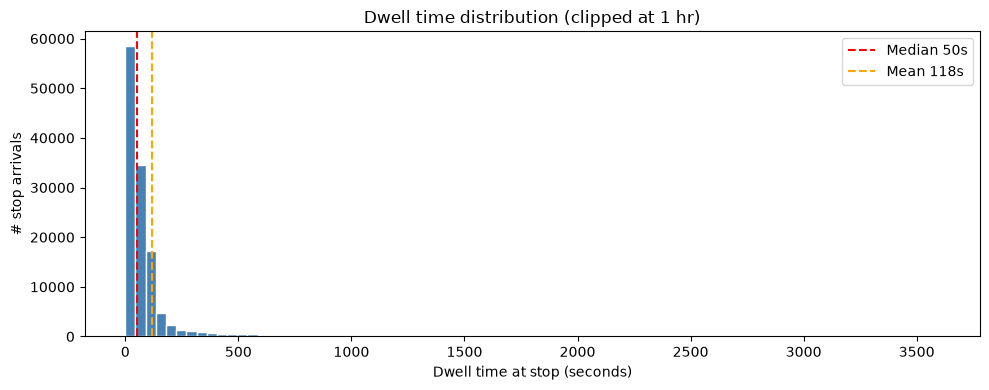

In [7]:
# Dwell time distribution (how long buses sit at stops)
if len(fa):
    dwell = fa[fa["matched"]]["dwell_s"].clip(upper=3600)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(dwell, bins=80, color="steelblue", edgecolor="white")
    ax.axvline(dwell.median(), color="red",    ls="--", label=f"Median {dwell.median():.0f}s")
    ax.axvline(dwell.mean(),   color="orange", ls="--", label=f"Mean {dwell.mean():.0f}s")
    ax.set_xlabel("Dwell time at stop (seconds)"); ax.set_ylabel("# stop arrivals")
    ax.set_title("Dwell time distribution (clipped at 1 hr)"); ax.legend()
    plt.tight_layout(); plt.show()

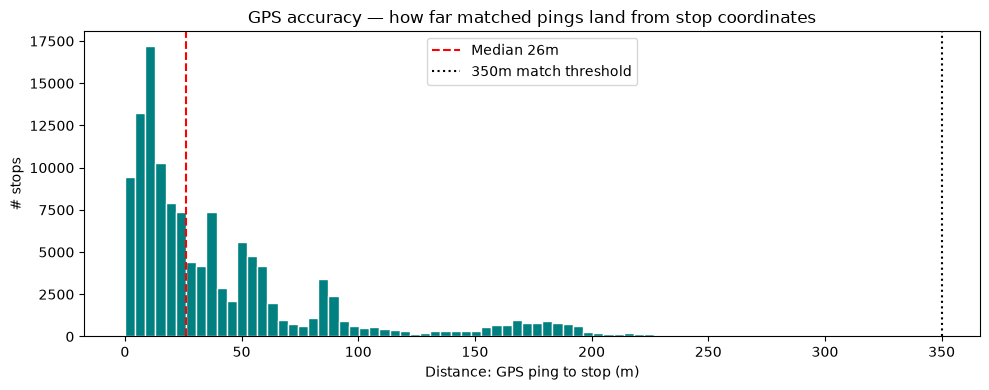

Within 50m: 69.1%  |  Within 100m: 88.2%  |  Within 200m: 97.6%


In [8]:
# GPS-to-stop distance distribution (accuracy of stop coordinates)
if len(fa):
    dist = fa[fa["matched"]]["dist_m"]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(dist, bins=80, color="teal", edgecolor="white")
    ax.axvline(dist.median(), color="red",   ls="--", label=f"Median {dist.median():.0f}m")
    ax.axvline(350,           color="black", ls=":",  label="350m match threshold")
    ax.set_xlabel("Distance: GPS ping to stop (m)"); ax.set_ylabel("# stops")
    ax.set_title("GPS accuracy — how far matched pings land from stop coordinates")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"Within 50m: {(dist<=50).mean()*100:.1f}%  |  Within 100m: {(dist<=100).mean()*100:.1f}%  |  Within 200m: {(dist<=200).mean()*100:.1f}%")

### What is the Match Rate?

The **match rate** is the percentage of stops in a trip where a GPS ping was found within **350 meters** of the stop's coordinates.

```
Example trip — Line 209, KASSERINE → SFAX (22 stops):

  Stop 0  KASSERINE    → GPS ping found 39m away     ✓ matched
  Stop 1  BOUZGUEM     → GPS ping found 6m away      ✓ matched
  Stop 2  EL GARRAA    → GPS ping found 136m away    ✓ matched
  Stop 5  OUED ELMIOU  → nearest ping was 2,927m away ✗ NOT matched
  Stop 10 EL FAIDH     → nearest ping was 8,304m away ✗ NOT matched
  ...
  Stop 21 SFAX         → GPS ping found 101m away    ✓ matched

  Result: 13 matched / 22 total = 59% match rate
```

**Why is a stop unmatched?**
1. **Bad stop coordinates** — the lat/lon in the database is wrong (most common)
2. **GPS signal gap** — the bus passed through without sending a ping
3. **Bus skipped the stop** — rare but possible

**What does the match rate tell us?**
- **High match rate (>85%)**: stop coordinates are accurate, GPS coverage is good
- **Low match rate (<60%)**: stop coordinates need correction for that line
- **Overall 76%**: we're getting 3 out of 4 stops matched across all lines

The match rate is the **headline data quality signal** — it tells you which lines need their stop coordinates fixed before they can be used for delay prediction.

bus_days  trips  stops  match_rate
societe line                                    
S.R.T.K 501          2      1      3       100.0
S.T.S   107          1      4     34       100.0
        225          3      2     73        98.6
S.R.T.K 306        144      4   1054        94.6
S.T.S   216          7      3     33        87.9
        301         28      6    850        86.8
S.R.T.K 211          5      3     87        85.1
S.T.S   306         52      2   2538        84.5
S.R.T.K 415          4      2     31        83.9
TCV     3          405     23  85412        82.6
S.T.S   226         19      4    725        81.9
S.R.T.K 202        115      3   4749        80.5
S.T.S   211         37     10   1251        79.0
S.R.T.K 500         10      3    108        78.7
        428          6      2     42        78.6
S.T.S   101        145     24   6582        76.8
        219         62     23  11732        75.2
S.R.T.K 209        127      3   4922        74.2
S.T.S   304        226      4  10506        71.0
        541          2      7    122        70.5
S.R.T.K 217        153      4   7699        70.1
        216         30      2   1413        68.5
        204        116      3   3811        68.2
        203        147      3   5513        67.7
S.T.S   215          8      4     94        63.8
S.R.T.K 205         13      2    129        61.2
        215        148      3   6207        61.0
        311          5      2     50        60.0
        212        280      4  12552        55.1
        201          6      2    140        48.6
        402          1      1      5        40.0
S.T.S   515          1      1      9        11.1
S.R.T.K 424          1      1      1         0.0
S.T.S   212          1      1      4         0.0

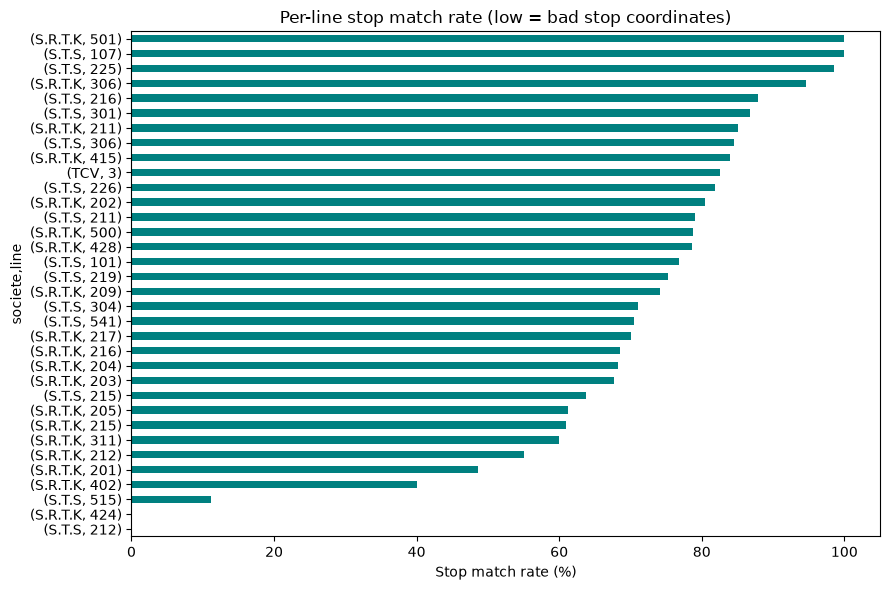

In [9]:
# Stop match rate per line (main data-quality signal)
if len(fa):
    per_line = (fa.groupby(["societe","line"])
                  .agg(bus_days=("day","nunique"), trips=("trip_id","nunique"),
                       stops=("matched","size"), match_rate=("matched","mean"))
                  .assign(match_rate=lambda d: (d["match_rate"]*100).round(1))
                  .sort_values("match_rate", ascending=False))
    display(per_line)
    per_line["match_rate"].sort_values().plot(kind="barh", figsize=(9, 6), color="teal")
    plt.xlabel("Stop match rate (%)"); plt.title("Per-line stop match rate (low = bad stop coordinates)")
    plt.tight_layout(); plt.show()

In [10]:
# Data volume and match rate by company
if len(fa):
    by_company = (fa.groupby("societe")
                    .agg(rows=("day","size"), lines=("line","nunique"),
                         buses=("bus","nunique"), days=("day","nunique"),
                         match_rate=("matched","mean"))
                    .assign(match_rate=lambda d: (d["match_rate"]*100).round(1))
                    .sort_values("rows", ascending=False))
    print("Data volume and match rate by company:")
    display(by_company)

Data volume and match rate by company:


,rows,lines,buses,days,match_rate
societe,,,,,
TCV,85412,1,11,405,82.6
S.R.T.K,48516,19,19,459,66.5
S.T.S,34553,14,5,381,75.5


In [11]:
# Direction coverage: ALLER (outbound) vs RETOUR (return)
if len(fa):
    by_dir = (fa.groupby("dir")
                .agg(rows=("day","size"), trips=("trip_id","nunique"),
                     match_rate=("matched","mean"))
                .assign(match_rate=lambda d: (d["match_rate"]*100).round(1)))
    print("Coverage by direction (ALLER=outbound, RETOUR=return):")
    print(by_dir.to_string())

Coverage by direction (ALLER=outbound, RETOUR=return):
         rows  trips  match_rate
dir                             
ALLER   84382     23        80.5
RETOUR  84099     24        72.5


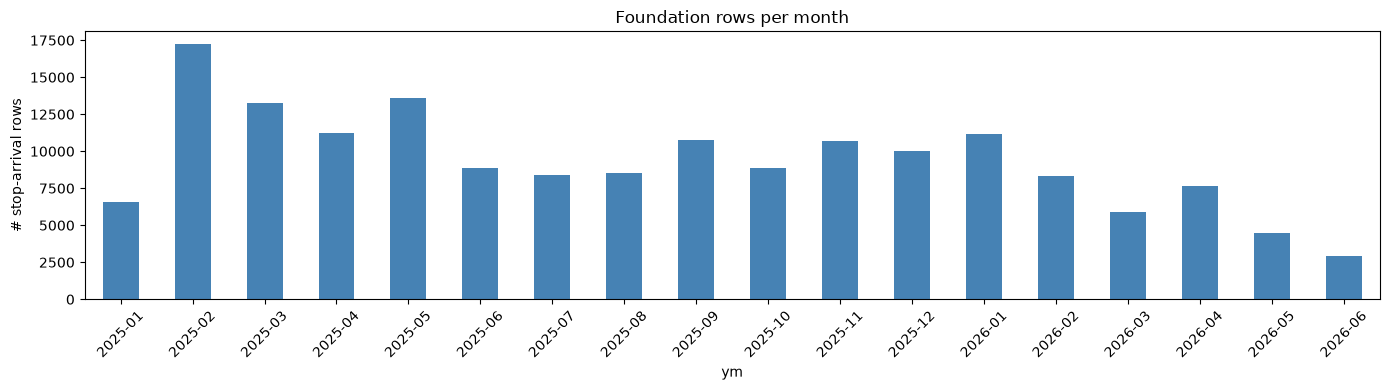

          rows  days  trips  match_rate
ym                                     
2025-01   6599    24     23        78.1
2025-02  17240    28     23        81.5
2025-03  13248    31     18        76.2
2025-04  11216    30     22        78.9
2025-05  13609    31     23        80.2
2025-06   8896    29     22        80.6
2025-07   8405    31     22        80.9
2025-08   8506    30     23        79.1
2025-09  10791    30     23        73.1
2025-10   8871    31     23        71.3
2025-11  10665    30     24        75.1
2025-12   9990    31     22        79.2
2026-01  11185    31     22        74.5
2026-02   8335    28     22        72.5
2026-03   5897    29     20        72.2
2026-04   7675    30     20        68.8
2026-05   4445    26     20        68.4
2026-06   2908    21     21        70.2


In [12]:
# Monthly data volume (temporal spread across 18 months)
if len(fa):
    tmp = fa.copy()
    tmp["ym"] = pd.to_datetime(tmp["day"], format="%Y%m%d").dt.to_period("M")
    by_month = (tmp.groupby("ym")
                   .agg(rows=("day","size"), days=("day","nunique"),
                        trips=("trip_id","nunique"), match_rate=("matched","mean"))
                   .assign(match_rate=lambda d: (d["match_rate"]*100).round(1)))
    by_month["rows"].plot(kind="bar", figsize=(14, 4), color="steelblue")
    plt.ylabel("# stop-arrival rows"); plt.title("Foundation rows per month")
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    print(by_month.to_string())

### Monthly Volume Analysis — Key Findings

**Rows per day** (rows ÷ days) is more informative than raw row count since months have different lengths:

```
2025-01:   275 rows/day   ← low baseline
2025-02:   616 rows/day   ← sudden spike (something was added)
2025-03:   427 rows/day
2025-05:   439 rows/day
2025-09:   360 rows/day   ← gradual decline begins
2026-01:   361 rows/day
2026-04:   256 rows/day
2026-05:   171 rows/day
2026-06:   138 rows/day   ← partial month (data ends June 21)
```

**⚠️ The `trips` column is misleading** — `trip_id` resets to 0, 1, 2... per bus-day, so
`nunique()` across a month gives the max trips any single bus did in a day (~3), not the
total trips that month. Ignore it.

---

#### What explains the patterns?

**Feb 2025 spike (275 → 616 rows/day)**
A sudden 2.2× jump in a single month points to new GPS trackers being installed or a new
company's fleet coming online — not a gradual growth. Something was added.

**2026 decline (360 → 138 rows/day)**
The most likely explanation is **GPS trackers going offline** (broken, removed, or not
replaced). With only 35 unique bus vehicles across the whole dataset, even 3–4 trackers
going dark cuts volume significantly. Other possible causes:
- Buses taken out of service
- Companies reducing operations
- Foundation build script not yet run on the most recent days

**Falling match rate (81.5% → 68.4%)**
This is a separate trend from the volume drop. Possible causes:
- Different lines becoming active in 2026 that have worse stop coordinates
- GPS schema drift — we already found `direction` went 98% null in 2026; if position
  precision also degraded, pings land further from stops
- Fewer buses per line means fewer redundant pings near each stop, making misses more likely

**Verification:** cross-check `fa.groupby('ym')['bus'].nunique()` — if the number of unique
bus IDs drops in 2026, GPS trackers are confirmed going offline.

         active_buses   rows  rows_per_day
ym                                        
2025-01            10   6599         275.0
2025-02            18  17240         616.0
2025-03            15  13248         427.0
2025-04            13  11216         374.0
2025-05            15  13609         439.0
2025-06            14   8896         307.0
2025-07            15   8405         271.0
2025-08            15   8506         284.0
2025-09            19  10791         360.0
2025-10            16   8871         286.0
2025-11            22  10665         356.0
2025-12            20   9990         322.0
2026-01            18  11185         361.0
2026-02            16   8335         298.0
2026-03            17   5897         203.0
2026-04            17   7675         256.0
2026-05            13   4445         171.0
2026-06            17   2908         138.0


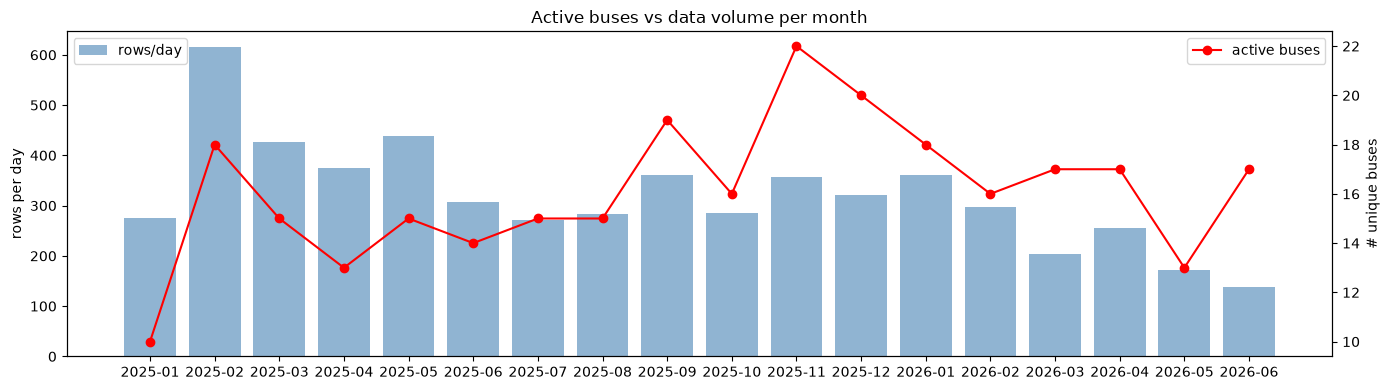

In [13]:
# Verify: unique active buses per month — confirms whether trackers are going offline
if len(fa):
    tmp = fa.copy()
    tmp["ym"] = pd.to_datetime(tmp["day"], format="%Y%m%d").dt.to_period("M")
    by_month_bus = tmp.groupby("ym").agg(
        active_buses=("bus", "nunique"),
        rows=("day", "size"),
        rows_per_day=("day", lambda x: len(x) / x.nunique())
    ).round(0)
    print(by_month_bus.to_string())

    fig, ax1 = plt.subplots(figsize=(14, 4))
    ax2 = ax1.twinx()
    ax1.bar(by_month_bus.index.astype(str), by_month_bus["rows_per_day"], color="steelblue", alpha=0.6, label="rows/day")
    ax2.plot(by_month_bus.index.astype(str), by_month_bus["active_buses"], color="red", marker="o", label="active buses")
    ax1.set_ylabel("rows per day"); ax2.set_ylabel("# unique buses")
    ax1.set_title("Active buses vs data volume per month")
    plt.xticks(rotation=45)
    ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
    plt.tight_layout(); plt.show()

In [14]:
# Foundation quality scorecard — summary
if len(fa):
    n_trips   = fa.groupby(["day","line","bus","trip_id"]).ngroups
    n_busdays = fa.groupby(["day","line","bus"]).ngroups
    n_full    = fa.groupby(["day","line","bus","trip_id"])["full"].first().sum()
    match_pct = fa["matched"].mean() * 100
    def grade(v, lo, hi): return "EXCELLENT" if v >= hi else "GOOD" if v >= lo else "NEEDS WORK"
    print("=" * 55)
    print("FOUNDATION DATASET  —  QUALITY SCORECARD")
    print("=" * 55)
    print(f"  Rows (stop arrivals)  : {len(fa):,}")
    print(f"  Bus-days              : {n_busdays:,}")
    print(f"  Trips                 : {n_trips:,}")
    print(f"  Lines                 : {fa['line'].nunique()}")
    print(f"  Companies             : {fa['societe'].nunique()}")
    print(f"  Date range            : {fa['day'].min()} -> {fa['day'].max()}")
    print(f"  Stop match rate       : {match_pct:.1f}%  [{grade(match_pct, 65, 85)}]")
    print(f"  Full trip rate        : {n_full/n_trips*100:.1f}%")
    print("=" * 55)

FOUNDATION DATASET  —  QUALITY SCORECARD
  Rows (stop arrivals)  : 168,481
  Bus-days              : 3,343
  Trips                 : 20,743
  Lines                 : 29
  Companies             : 3
  Date range            : 20250101 -> 20260621
  Stop match rate       : 76.5%  [GOOD]
  Full trip rate        : 83.6%
